NOME: Hercules André
DISCIPLINA: Otimização
Machine Scheduling - Instâncias:

/machinescheduling_instances: Machine Scheduling Instances
Desenvolver em linguagem Julia, usando solver HiGHS. Configuração do solver livre. Isso inclui tempo de execução, gap de otimalidade, tolerâncias.


inst_n05_s01
===============================

In [17]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# Configuração do solver global
const SOLVER = HiGHS.Optimizer

HiGHS.Optimizer

In [18]:
# =====================================================
# 1. INSTÂNCIA E DADOS DO PROBLEMA (inst_n05_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5"],
    r   = [1, 14, 6, 13, 12],  # Tempo de liberação (release date)
    p   = [6, 10, 8, 10, 4],   # Tempo de processamento
    d   = [8, 32, 14, 34, 18]  # Data limite (due date)
)

n = nrow(jobs)
println("--- Dados dos Jobs (inst_n05_s01) ---")
println(jobs, "\n")

--- Dados dos Jobs (inst_n05_s01) ---
5×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          1      6      8
   2 │ J2         14     10     32
   3 │ J3          6      8     14
   4 │ J4         13     10     34
   5 │ J5         12      4     18



In [19]:
# =====================================================
# 2. FUNÇÕES HEURÍSTICAS DE AVALIAÇÃO
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)

    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end

    return maximum(atraso), inicio, fim
end

function imprimir_resultados(nome, ordem, inicio, fim)
    println("\n" * "="^52)
    println(" Heurística: ", nome)
    println("="^52)

    resultado = DataFrame(
        Ordem     = 1:length(ordem),
        Job       = jobs.Job[ordem],
        r         = jobs.r[ordem],
        p         = jobs.p[ordem],
        d         = jobs.d[ordem],
        Inicio    = inicio[ordem],
        Termino   = fim[ordem],
        Tardiness = max.(0, fim[ordem] .- jobs.d[ordem])
    )

    println(resultado)
    println("\nAtraso Máximo ($nome) = ", maximum(resultado.Tardiness))
end

imprimir_resultados (generic function with 1 method)

In [20]:
# =====================================================
# 3. EXECUÇÃO DAS HEURÍSTICAS (FIFO, SPT, EDD)
# =====================================================

# FIFO (First In, First Out) - Por tempo de liberação
fifo = sortperm(jobs.r)
obj_fifo, ini_fifo, fim_fifo = avaliar(fifo)

# SPT (Shortest Processing Time) - Por tempo de processamento
spt = sortperm(jobs.p)
obj_spt, ini_spt, fim_spt = avaliar(spt)

# EDD (Earliest Due Date) - Por data limite
edd = sortperm(jobs.d)
obj_edd, ini_edd, fim_edd = avaliar(edd)

# Imprimir o detalhamento de cada regra
imprimir_resultados("FIFO", fifo, ini_fifo, fim_fifo)
imprimir_resultados("SPT", spt, ini_spt, fim_spt)
imprimir_resultados("EDD", edd, ini_edd, fim_edd)


 Heurística: FIFO
5×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Tardiness 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64     
─────┼────────────────────────────────────────────────────────────────
   1 │     1  J1          1      6      8       1        7          0
   2 │     2  J3          6      8     14       7       15          1
   3 │     3  J5         12      4     18      15       19          1
   4 │     4  J4         13     10     34      19       29          0
   5 │     5  J2         14     10     32      29       39          7

Atraso Máximo (FIFO) = 7

 Heurística: SPT
5×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Tardiness 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64     
─────┼────────────────────────────────────────────────────────────────
   1 │     1  J5         12      4     18      12       16          0
   2 │     2  J1          1      6      8      16       22     

In [21]:
# =====================================================
# 4. MODELO DE PROGRAMAÇÃO LINEAR INTEIRA MISTA (MILP)
# =====================================================
M = sum(jobs.p) + maximum(jobs.r) + 10

modelo = Model(SOLVER)
set_silent(modelo)

# Parâmetros e tolerâncias do solver (Definidos antes do optimize!)
set_attribute(modelo, "mip_rel_gap", 1e-4)                # GAP relativo (0,01%)
set_attribute(modelo, "mip_abs_gap", 1e-6)                # GAP absoluto
set_attribute(modelo, "time_limit", 600.0)                # Limite de tempo (600 s)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de decisão
@variable(modelo, s[1:n] >= 0)       # Tempo de início de cada tarefa
@variable(modelo, T >= 0)            # Atraso Máximo (Tardiness)
@variable(modelo, x[1:n, 1:n], Bin)  # Variável binária de precedência

# Restrições
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

# Função Objetivo
@objective(modelo, Min, T)

# Otimização
optimize!(modelo)

println("\n" * "="^52)
println("        RESULTADOS DA OTIMIZAÇÃO (MILP)         ")
println("="^52)
println("Status da Solução = ", termination_status(modelo))

T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)


        RESULTADOS DA OTIMIZAÇÃO (MILP)         
Status da Solução = OPTIMAL


5-element Vector{Int64}:
 1
 3
 5
 2
 4

In [22]:
# =====================================================
# 5. ANÁLISE DE RESULTADOS E COMPARAÇÕES (GAPs)
# =====================================================
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

# Identificar a melhor heurística
nomes = ["FIFO", "SPT", "EDD"]
valores = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores)
melhor_regra = nomes[indice_melhor]

# DataFrame Comparativo Final
resultado_final = DataFrame(
    Metodo         = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo  = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0]
)

println("\n--- Tabela Comparativa de Métodos ---")
println(resultado_final)
println("\nMelhor Regra Heurística: ", melhor_regra)
println("Ótimo Exato Encontrado (MILP): ", T_otimo)


--- Tabela Comparativa de Métodos ---
4×3 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Percentual 
     │ String  Float64        Float64        
─────┼───────────────────────────────────────
   1 │ FIFO              7.0            40.0
   2 │ SPT              16.0           220.0
   3 │ EDD               5.0             0.0
   4 │ MILP              5.0             0.0

Melhor Regra Heurística: EDD
Ótimo Exato Encontrado (MILP): 5.0


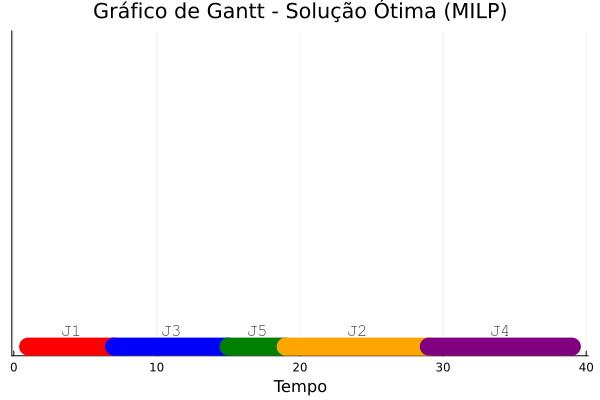

GKS: could not find font bold.ttf


In [23]:
# =====================================================
# 6. GERAÇÃO DO GRÁFICO DE GANTT
# =====================================================
cores = [:red, :blue, :green, :orange, :purple, :cyan, :pink, :yellow]

gantt = plot(
    legend = false,
    xlabel = "Tempo",
    ylabel = "",
    yticks = [],
    title  = "Gráfico de Gantt - Solução Ótima (MILP)"
)

for (k, j) in enumerate(ordem_otima)
    plot!(gantt,
        [inicio_milp[j], fim_milp[j]],
        [1, 1],
        lw    = 18,
        color = cores[k]
    )

    annotate!(gantt, (
        (inicio_milp[j] + fim_milp[j]) / 2,
        1.05,
        text(jobs.Job[j], :black, :bold, 9)
    ))
end

display(gantt)

InstÂncia inst_n05_s02
=======================

In [24]:
# =====================================================
# 1. GERENCIAMENTO DE PACOTES E IMPORTAÇÕES
# =====================================================
import Pkg

function garantir_pacotes(pkgs)
    for p in pkgs
        try
            @eval using $(Symbol(p))
        catch
            println("Instalando o pacote: $p...")
            Pkg.add(p)
            @eval using $(Symbol(p))
        end
    end
end

# Garante que todas as dependências estejam prontas
garantir_pacotes(["JuMP", "HiGHS", "DataFrames", "Printf", "Plots"])

# Definição do Solver Global
const SOLVER = HiGHS.Optimizer

HiGHS.Optimizer

In [25]:
# =====================================================
# 2. CONFIGURAÇÃO DOS DADOS DA INSTÂNCIA
# =====================================================
# Instância: inst_n05_s02
nome_instancia = "inst_n05_s02"
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5"],
    r   = [5, 8, 11, 4, 14],   # Tempo de liberação
    p   = [5, 6, 10, 3, 6],   # Tempo de processamento
    d   = [11, 23, 24, 13, 20] # Data limite (Due Date)
)
n = nrow(jobs)

println("=====================================================")
println("          EXECUTANDO: $nome_instancia")
println("=====================================================")
println(jobs)

          EXECUTANDO: inst_n05_s02
5×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          5      5     11
   2 │ J2          8      6     23
   3 │ J3         11     10     24
   4 │ J4          4      3     13
   5 │ J5         14      6     20


In [26]:
# =====================================================
# 3. FUNÇÃO DE AVALIAÇÃO DE SEQUÊNCIAS
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    return maximum(atraso), inicio, fim
end

avaliar (generic function with 1 method)

In [27]:
# =====================================================
# 4. HEURÍSTICAS DE ORDENAÇÃO (REGRAS DE DESPACHO)
# =====================================================
# FIFO (First In, First Out) - Por ordem de chegada (r)
fifo = sortperm(jobs.r)
obj_fifo, ini_fifo, fim_fifo = avaliar(fifo)

# SPT (Shortest Processing Time) - Por tempo de processamento (p)
spt = sortperm(jobs.p)
obj_spt, ini_spt, fim_spt = avaliar(spt)

# EDD (Earliest Due Date) - Por data limite (d)
edd = sortperm(jobs.d)
obj_edd, ini_edd, fim_edd = avaliar(edd)

(12, [5, 20, 26, 10, 14], [10, 26, 36, 13, 20])

In [28]:
# =====================================================
# 5. MODELO MATEMÁTICO MILP
# =====================================================
# Grande M para linearização das restrições de precedência
M = sum(jobs.p) + maximum(jobs.r) + 10

modelo = Model(SOLVER)
set_silent(modelo)

# Configuração de Tolerâncias e Atributos do HiGHS
set_attribute(modelo, "mip_rel_gap", 1e-4)                  # GAP relativo (0,01%)
set_attribute(modelo, "mip_abs_gap", 1e-6)                  # GAP absoluto
set_attribute(modelo, "time_limit", 600.0)                  # Limite de tempo (600s)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)       # Instante de início de cada tarefa
@variable(modelo, T >= 0)            # Atraso máximo (Tardiness)
@variable(modelo, x[1:n, 1:n], Bin)  # 1 se i antecede j; 0 caso contrário

# Restrições
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

# Objetivo: Minimizar o Atraso Máximo
@objective(modelo, Min, T)

# Otimização
optimize!(modelo)

# Extração dos Resultados do MILP
status = termination_status(modelo)
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

5-element Vector{Int64}:
 4
 1
 2
 5
 3

In [29]:
# =====================================================
# 6. ANÁLISE DE RESULTADOS E CÁLCULO DE GAP
# =====================================================
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

# Identificação da melhor heurística
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
melhor_regra = nomes_regras[argmin(valores_regras)]

# Tabela Consolidada de Métodos
df_consolidado = DataFrame(
    Metodo        = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0]
)

println("\n=== TABELA COMPARATIVA DE RESULTADOS ===")
println(df_consolidado)
println("\nStatus do Solver: ", status)
println("Melhor Regra Heurística: ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)


=== TABELA COMPARATIVA DE RESULTADOS ===
4×3 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Percentual 
     │ String  Float64        Float64        
─────┼───────────────────────────────────────
   1 │ FIFO             14.0    40.0
   2 │ SPT              10.0     5.50671e-13
   3 │ EDD              12.0    20.0
   4 │ MILP             10.0     0.0

Status do Solver: OPTIMAL
Melhor Regra Heurística: SPT
Atraso Máximo Ótimo (MILP): 9.999999999999945


In [30]:
# =====================================================
# 7. FUNÇÃO PARA IMPRESSÃO DETALHADA POR MÉTODO
# =====================================================
function imprimir_detalhes_regra(nome, ordem, inicio, fim)
    println("\n" * "="^53)
    println(" DETALHAMENTO DA SEQUÊNCIA: ", nome)
    println("="^53)
    
    df_detalhe = DataFrame(
        Ordem     = 1:length(ordem),
        Job       = jobs.Job[ordem],
        r         = jobs.r[ordem],
        p         = jobs.p[ordem],
        d         = jobs.d[ordem],
        Inicio    = inicio[ordem],
        Termino   = fim[ordem],
        Tardiness = max.(0, fim[ordem] .- jobs.d[ordem])
    )
    println(df_detalhe)
    println("Atraso Máximo verificado: ", maximum(df_detalhe.Tardiness))
end

# Exibindo o detalhamento das regras e do modelo ótimo
imprimir_detalhes_regra("FIFO", fifo, ini_fifo, fim_fifo)
imprimir_detalhes_regra("EDD", edd, ini_edd, fim_edd)
imprimir_detalhes_regra("MILP (ÓTIMO)", ordem_otima, inicio_milp, fim_milp)


 DETALHAMENTO DA SEQUÊNCIA: FIFO
5×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Tardiness 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64     
─────┼────────────────────────────────────────────────────────────────
   1 │     1  J4          4      3     13       4        7          0
   2 │     2  J1          5      5     11       7       12          1
   3 │     3  J2          8      6     23      12       18          0
   4 │     4  J3         11     10     24      18       28          4
   5 │     5  J5         14      6     20      28       34         14
Atraso Máximo verificado: 14

 DETALHAMENTO DA SEQUÊNCIA: EDD
5×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Tardiness 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64     
─────┼────────────────────────────────────────────────────────────────
   1 │     1  J1          5      5     11       5       10          0
   2 │     2  J4          4   

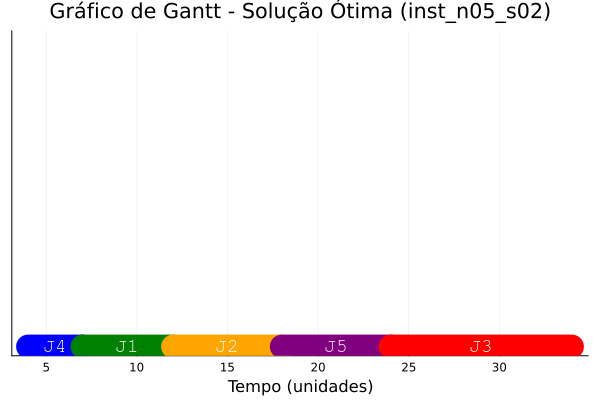

In [31]:
# =====================================================
# 8. GERAÇÃO DO GRÁFICO DE GANTT (SOLUÇÃO ÓTIMA)
# =====================================================
cores = [:red, :blue, :green, :orange, :purple]

gantt = plot(
    legend=false, 
    xlabel="Tempo (unidades)", 
    ylabel="", 
    yticks=[], 
    title="Gráfico de Gantt - Solução Ótima ($nome_instancia)"
)

for (k, j) in enumerate(ordem_otima)
    # Desenha a barra da tarefa
    plot!(gantt, 
          [inicio_milp[j], fim_milp[j]], 
          [1, 1], 
          lw=24, 
          color=cores[k % length(cores) + 1])
    
    # Adiciona rótulo de identificação textual centralizado na barra
    annotate!(gantt, 
              ((inicio_milp[j] + fim_milp[j]) / 2, 1.0, 
               text(jobs.Job[j], :white, :center, 10, :bold)))
end

display(gantt)

INSTÂNCIA (inst_n05_s03)
=============

In [32]:
# ==============================================================================
# 1. INSTALAÇÃO AUTOMATIZADA E CARREGAMENTO DE PACOTES
# ==============================================================================
import Pkg
function assegurar_pacotes(pacotes)
    for p in pacotes
        try
            @eval using $(Symbol(p))
        catch
            Pkg.add(p)
            @eval using $(Symbol(p))
        end
    end
end
assegurar_pacotes(["JuMP", "HiGHS", "DataFrames", "Printf", "Plots"])

using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

const SOLVER = HiGHS.Optimizer

HiGHS.Optimizer

In [33]:
# ==============================================================================
# 2. CONFIGURAÇÃO DOS DADOS DA INSTÂNCIA (inst_n05_s03)
# ==============================================================================
nome_instancia = "inst_n05_s03"
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5"],
    r   = [0, 0, 4, 4, 6],   # Tempo de liberação
    p   = [2, 2, 1, 7, 1],   # Tempo de processamento
    d   = [3, 4, 9, 11, 10]  # Data limite (Due Date)
)
n = nrow(jobs)

println("=== Dados da Instância: $nome_instancia ===")
println(jobs)

=== Dados da Instância: inst_n05_s03 ===
5×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          0      2      3
   2 │ J2          0      2      4
   3 │ J3          4      1      9
   4 │ J4          4      7     11
   5 │ J5          6      1     10


In [34]:
# ==============================================================================
# 3. FUNÇÃO DE AVALIAÇÃO DE SEQUÊNCIAS (HEURÍSTICAS)
# ==============================================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    return maximum(atraso), inicio, fim
end

# Execução das Regras de Despacho
fifo = sortperm(jobs.r)
obj_fifo, ini_fifo, fim_fifo = avaliar(fifo)

spt = sortperm(jobs.p)
obj_spt, ini_spt, fim_spt = avaliar(spt)

edd = sortperm(jobs.d)
obj_edd, ini_edd, fim_edd = avaliar(edd)

(3, [0, 2, 4, 7, 6], [2, 4, 5, 14, 7])

In [35]:
# ==============================================================================
# 4. MODELO MATEMÁTICO (MILP)
# ==============================================================================
M = sum(jobs.p) + maximum(jobs.r) + 10

modelo = Model(SOLVER)
set_silent(modelo)

# Configuração de Tolerâncias e Limites do Solver (Antes do optimize!)
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, T >= 0)
@variable(modelo, x[1:n, 1:n], Bin)

# Restrições
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

# Coleta de Resultados do MILP
status = termination_status(modelo)
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

5-element Vector{Int64}:
 1
 2
 3
 4
 5

In [36]:
# ==============================================================================
# 5. ANÁLISE COMPARATIVA E GAIN/GAP
# ==============================================================================
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

nomes = ["FIFO", "SPT", "EDD"]
valores = [obj_fifo, obj_spt, obj_edd]
melhor_regra = nomes[argmin(valores)]

resultado_global = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0]
)

Row,Metodo,Atraso_Maximo,GAP_Percentual
,String,Float64,Float64
1,FIFO,3.0,0.0
2,SPT,7.0,133.333
3,EDD,3.0,0.0
4,MILP,3.0,0.0


In [37]:
# ==============================================================================
# 6. IMPRESSÃO DOS RESULTADOS DETALHADOS
# ==============================================================================
function imprimir_resultados(nome, ordem, inicio_proc, fim_proc)
    println("\n" * "="^50)
    println("ULTRADETALHADO: ", nome)
    println("="^50)
    res = DataFrame(
        Ordem = 1:length(ordem),
        Job = jobs.Job[ordem],
        r = jobs.r[ordem],
        p = jobs.p[ordem],
        d = jobs.d[ordem],
        Inicio = inicio_proc[ordem],
        Termino = fim_proc[ordem],
        Tardiness = max.(0, fim_proc[ordem] .- jobs.d[ordem])
    )
    println(res)
    println("-"^50)
    @printf("Atraso Máximo (%s) = %.2f\n", nome, maximum(res.Tardiness))
end

# Exibindo tabelas de cada método
imprimir_resultados("FIFO", fifo, ini_fifo, fim_fifo)
imprimir_resultados("SPT", spt, ini_spt, fim_spt)
imprimir_resultados("EDD", edd, ini_edd, fim_edd)
imprimir_resultados("MILP (Ótimo)", ordem_otima, inicio_milp, fim_milp)

println("\n" * "="^50)
println("RESUMO COMPARATIVO DOS MÉTODOS")
println("="^50)
println(resultado_global)
println("\nStatus do Solver = ", status)
println("Melhor Regra Heurística = ", melhor_regra)
println("Ótimo Encontrado pelo MILP = ", T_otimo)


ULTRADETALHADO: FIFO
5×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Tardiness 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64     
─────┼────────────────────────────────────────────────────────────────
   1 │     1  J1          0      2      3       0        2          0
   2 │     2  J2          0      2      4       2        4          0
   3 │     3  J3          4      1      9       4        5          0
   4 │     4  J4          4      7     11       5       12          1
   5 │     5  J5          6      1     10      12       13          3
--------------------------------------------------
Atraso Máximo (FIFO) = 3.00

ULTRADETALHADO: SPT
5×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Tardiness 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64     
─────┼────────────────────────────────────────────────────────────────
   1 │     1  J3          4      1      9       4        5          0
   2

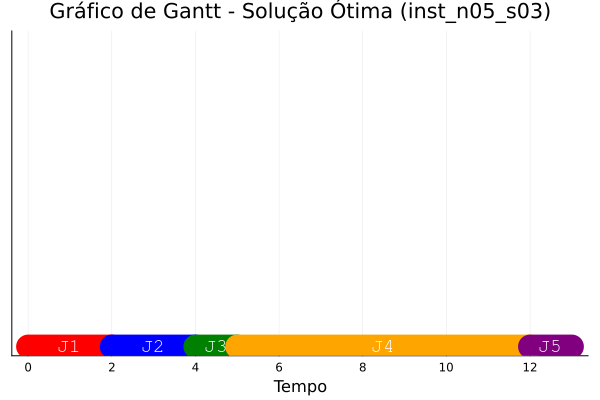

In [38]:
# ==============================================================================
# 7. GERAÇÃO DO GRÁFICO DE GANTT (SOLUÇÃO ÓTIMA MILP)
# ==============================================================================
cores = [:red, :blue, :green, :orange, :purple, :cyan, :pink, :yellow]
gantt = plot(
    legend = false,
    xlabel = "Tempo",
    ylabel = "",
    yticks = [],
    title = "Gráfico de Gantt - Solução Ótima ($nome_instancia)"
)

for (k, j) in enumerate(ordem_otima)
    plot!(
        gantt,
        [inicio_milp[j], fim_milp[j]],
        [1, 1],
        lw = 24,
        color = cores[mod1(k, length(cores))]
    )
    # Texto centralizado de forma resiliente com cor branca para legibilidade
    annotate!(
        gantt,
        ((inicio_milp[j] + fim_milp[j]) / 2, 1.0, 
         text(jobs.Job[j], :white, :center, 10, :bold))
    )
end

display(gantt)

Instância (inst_n07_s01)
==============

In [39]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# Constante para o Solver
const SOLVER = HiGHS.Optimizer

HiGHS.Optimizer

In [40]:
# =====================================================
# Dados da Instância inst_n07_s01
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7"],
    r   = [12, 20, 5, 18, 9, 28, 16],
    p   = [9, 10, 4, 10, 6, 8, 8],
    d   = [21, 42, 20, 35, 19, 38, 36]
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
7×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         12      9     21
   2 │ J2         20     10     42
   3 │ J3          5      4     20
   4 │ J4         18     10     35
   5 │ J5          9      6     19
   6 │ J6         28      8     38
   7 │ J7         16      8     36



In [41]:
# =====================================================
# Função de Avaliação de Sequência
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    return maximum(atraso), inicio, fim
end

avaliar (generic function with 1 method)

In [42]:
# =====================================================
# Heurísticas de Sequenciamento
# =====================================================

# 1. FIFO (First-In, First-Out)
fifo = sortperm(jobs.r)
obj_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Shortest Processing Time)
spt = sortperm(jobs.p)
obj_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Earliest Due Date)
edd = sortperm(jobs.d)
obj_edd, inicio_edd, fim_edd = avaliar(edd)

(22, [19, 54, 15, 28, 9, 46, 38], [28, 64, 19, 38, 15, 54, 46])

In [43]:
# =====================================================
# Modelo de Programação Linear Inteira Mista (MILP)
# =====================================================
modelo = Model(SOLVER)

# Tolerâncias e Parâmetros do Solver (Configurados ANTES da otimização)
set_attribute(modelo, "mip_rel_gap", 1e-4)        # GAP relativo (0,01%)
set_attribute(modelo, "mip_abs_gap", 1e-6)        # GAP absoluto
set_attribute(modelo, "time_limit", 600.0)        # Limite de tempo (600 s)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, T >= 0)
@variable(modelo, x[1:n, 1:n], Bin)

# Constante Big-M
M = sum(jobs.p) + maximum(jobs.r)

# Restrições
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in (i+1):n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

# Objetivo: Minimizar o Atraso Máximo (Tardiness)
@objective(modelo, Min, T)

# Otimização
optimize!(modelo)

# Resultados do MILP
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 56 rows; 57 cols; 147 nonzeros; 49 integer variables (49 binary)
Coefficient ranges:
  Matrix  [1e+00, 8e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 8e+01]
Presolving model
49 rows, 29 cols, 140 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
Presolve reductions: rows 28(-28); columns 29(-28); nonzeros 77(-70) 

Solving MIP model with:
   28 rows
   29 cols (21 binary, 0 integer, 0 implied int., 8 continuous, 0 domain fixed)
   77 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z =>

7-element Vector{Int64}:
 3
 5
 1
 7
 6
 4
 2

In [44]:
# =====================================================
# Cálculo dos GAPs
# =====================================================
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

# Melhor Regra Heurística
nomes = ["FIFO", "SPT", "EDD"]
valores = [obj_fifo, obj_spt, obj_edd]
indice = argmin(valores)
melhor_regra = nomes[indice]

"FIFO"

In [45]:
# =====================================================
# Impressão de Tabelas Comparativas
# =====================================================
resultado_metodos = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0]
)

println("--- COMPARAÇÃO DE MÉTODOS ---")
println(resultado_metodos)
println()
println("Melhor Regra Heurística: ", melhor_regra)
println("Atraso Ótimo (MILP): ", T_otimo)
println()

# Função para detalhar cada regra
function imprimir_resultados(nome, ordem, inicio, fim)
    println("====================================================")
    println("                 MÉTODO: ", nome)
    println("====================================================")
    df_detalhe = DataFrame(
        Ordem   = 1:length(ordem),
        Job     = jobs.Job[ordem],
        r       = jobs.r[ordem],
        p       = jobs.p[ordem],
        d       = jobs.d[ordem],
        Inicio  = inicio[ordem],
        Termino = fim[ordem],
        Atraso  = max.(0, fim[ordem] .- jobs.d[ordem])
    )
    println(df_detalhe)
    println("Atraso Máximo = ", maximum(df_detalhe.Atraso))
    println()
end

# Imprimir o detalhamento da solução ótima encontrada pelo MILP
imprimir_resultados("MILP (ÓTIMO)", ordem_otima, inicio_milp, fim_milp)

--- COMPARAÇÃO DE MÉTODOS ---
4×3 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Percentual 
     │ String  Float64        Float64        
─────┼───────────────────────────────────────
   1 │ FIFO             22.0         22.2222
   2 │ SPT              38.0        111.111
   3 │ EDD              22.0         22.2222
   4 │ MILP             18.0          0.0

Melhor Regra Heurística: FIFO
Atraso Ótimo (MILP): 18.0

                 MÉTODO: MILP (ÓTIMO)
7×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Atraso 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64  
─────┼─────────────────────────────────────────────────────────────
   1 │     1  J3          5      4     20       5        9       0
   2 │     2  J5          9      6     19       9       15       0
   3 │     3  J1         12      9     21      15       24       3
   4 │     4  J7         16      8     36      24       32       0
   5 │     5  J6         28      8     38      32       40  

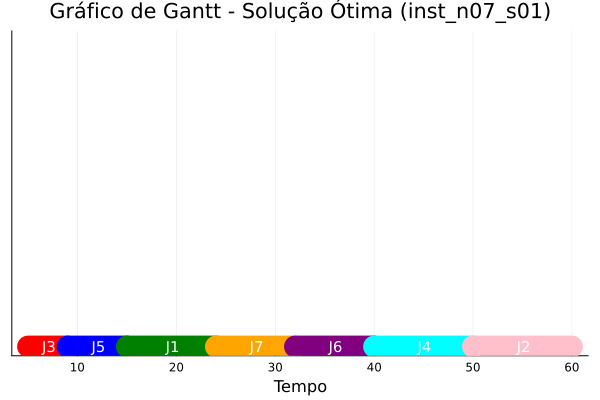

In [46]:
# =====================================================
# Gráfico de Gantt da Solução Ótima
# =====================================================
cores = [:red, :blue, :green, :orange, :purple, :cyan, :pink]

gantt = plot(
    legend=false, 
    xlabel="Tempo", 
    ylabel="", 
    yticks=[], 
    title="Gráfico de Gantt - Solução Ótima (inst_n07_s01)"
)

for (k, j) in enumerate(ordem_otima)
    plot!(gantt, 
          [inicio_milp[j], fim_milp[j]], 
          [1, 1], 
          lw=22, 
          color=cores[k])
          
    # Texto centralizado dentro das barras com contraste branco
    annotate!(gantt, 
              ((inicio_milp[j] + fim_milp[j]) / 2, 1.0, 
              text(jobs.Job[j], :white, :center, 10)))
end

display(gantt)

INSTÂNCIA (inst_n07_s02)
===============

In [ ]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n07_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7"],
    r   = [0, 11, 9, 3, 4, 5, 5],
    p   = [6, 5, 8, 6, 4, 5, 9],
    d   = [8, 24, 27, 17, 14, 18, 25]
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

In [52]:
# =====================================================
# Função de Avaliação de Sequência
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    return maximum(atraso), inicio, fim
end

avaliar (generic function with 1 method)

In [53]:
# =====================================================
# Heurísticas de Sequenciamento
# =====================================================

# 1. FIFO (First-In, First-Out)
fifo = sortperm(jobs.r)
obj_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Shortest Processing Time)
spt = sortperm(jobs.p)
obj_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Earliest Due Date)
edd = sortperm(jobs.d)
obj_edd, inicio_edd, fim_edd = avaliar(edd)

(16, [0, 21, 35, 10, 6, 16, 26], [6, 26, 43, 16, 10, 21, 35])

In [54]:
# =====================================================
# Modelo de Programação Linear Inteira Mista (MILP)
# =====================================================
modelo = Model(SOLVER)

# Tolerâncias e Parâmetros do Solver (Configurados ANTES da otimização)
set_attribute(modelo, "mip_rel_gap", 1e-4)        # GAP relativo (0,01%)
set_attribute(modelo, "mip_abs_gap", 1e-6)        # GAP absoluto
set_attribute(modelo, "time_limit", 600.0)        # Limite de tempo (600 s)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, T >= 0)
@variable(modelo, x[1:n, 1:n], Bin)

# Constante Big-M
M = sum(jobs.p) + maximum(jobs.r)

# Restrições
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in (i+1):n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

# Objetivo: Minimizar o Atraso Máximo (Tardiness)
@objective(modelo, Min, T)

# Otimização
optimize!(modelo)

# Resultados do MILP
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 56 rows; 57 cols; 147 nonzeros; 49 integer variables (49 binary)
Coefficient ranges:
  Matrix  [1e+00, 5e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e+00, 5e+01]
Presolving model
49 rows, 29 cols, 140 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
Presolve reductions: rows 28(-28); columns 29(-28); nonzeros 77(-70) 

Solving MIP model with:
   28 rows
   29 cols (21 binary, 0 integer, 0 implied int., 8 continuous, 0 domain fixed)
   77 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z =>

7-element Vector{Int64}:
 1
 5
 4
 6
 2
 7
 3

In [55]:
# =====================================================
# Cálculo dos GAPs
# =====================================================
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

# Melhor Regra Heurística
nomes = ["FIFO", "SPT", "EDD"]
valores = [obj_fifo, obj_spt, obj_edd]
indice = argmin(valores)
melhor_regra = nomes[indice]

"EDD"

In [56]:
# =====================================================
# Impressão de Tabelas Comparativas
# =====================================================
resultado_metodos = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0]
)

println("--- COMPARAÇÃO DE MÉTODOS ---")
println(resultado_metodos)
println()
println("Melhor Regra Heurística: ", melhor_regra)
println("Atraso Ótimo (MILP): ", T_otimo)
println()

# Função para detalhar cada regra
function imprimir_resultados(nome, ordem, inicio, fim)
    println("====================================================")
    println("                 MÉTODO: ", nome)
    println("====================================================")
    df_detalhe = DataFrame(
        Ordem   = 1:length(ordem),
        Job     = jobs.Job[ordem],
        r       = jobs.r[ordem],
        p       = jobs.p[ordem],
        d       = jobs.d[ordem],
        Inicio  = inicio[ordem],
        Termino = fim[ordem],
        Atraso  = max.(0, fim[ordem] .- jobs.d[ordem])
    )
    println(df_detalhe)
    println("Atraso Máximo = ", maximum(df_detalhe.Atraso))
    println()
end

# Imprimir o detalhamento da solução ótima encontrada pelo MILP
imprimir_resultados("MILP (ÓTIMO)", ordem_otima, inicio_milp, fim_milp)

--- COMPARAÇÃO DE MÉTODOS ---
4×3 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Percentual 
     │ String  Float64        Float64        
─────┼───────────────────────────────────────
   1 │ FIFO             19.0    18.75
   2 │ SPT              25.0    56.25
   3 │ EDD              16.0     2.66454e-13
   4 │ MILP             16.0     0.0

Melhor Regra Heurística: EDD
Atraso Ótimo (MILP): 15.999999999999957

                 MÉTODO: MILP (ÓTIMO)
7×8 DataFrame
 Row │ Ordem  Job     r      p      d      Inicio  Termino  Atraso 
     │ Int64  String  Int64  Int64  Int64  Int64   Int64    Int64  
─────┼─────────────────────────────────────────────────────────────
   1 │     1  J1          0      6      8       0        6       0
   2 │     2  J5          4      4     14       6       10       0
   3 │     3  J4          3      6     17      10       16       0
   4 │     4  J6          5      5     18      16       21       3
   5 │     5  J2         11      5     24      21       26       

In [1]:
# =====================================================
# Gráfico de Gantt da Solução Ótima
# =====================================================
cores = [:red, :blue, :green, :orange, :purple, :cyan, :pink]

gantt = plot(
    legend=false, 
    xlabel="Tempo", 
    ylabel="", 
    yticks=[], 
    title="Gráfico de Gantt - Solução Ótima (inst_n07_s02)"
)

for (k, j) in enumerate(ordem_otima)
    plot!(gantt, 
          [inicio_milp[j], fim_milp[j]], 
          [1, 1], 
          lw=22, 
          color=cores[k])
          
    # Texto centralizado dentro das barras com contraste branco
    annotate!(gantt, 
              ((inicio_milp[j] + fim_milp[j]) / 2, 1.0, 
              text(jobs.Job[j], :white, :center, 10)))
end

display(gantt)

LoadError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

INSTÂNCIA: inst_n07_s03
====================

In [79]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n07_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7"],
    r = [14, 4, 13, 10, 8, 0, 3],
    p = [5, 3, 7, 9, 10, 1, 6],
    d = [19, 13, 29, 28, 25, 13, 11]
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
7×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         14      5     19
   2 │ J2          4      3     13
   3 │ J3         13      7     29
   4 │ J4         10      9     28
   5 │ J5          8     10     25
   6 │ J6          0      1     13
   7 │ J7          3      6     11



In [80]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [81]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [82]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 56 rows; 57 cols; 147 nonzeros; 49 integer variables (49 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 5e+01]
Presolving model
49 rows, 29 cols, 140 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
Presolve reductions: rows 28(-28); columns 29(-28); nonzeros 77(-70) 

Solving MIP model with:
   28 rows
   29 cols (21 binary, 0 integer, 0 implied int., 8 continuous, 0 domain fixed)
   77 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z =>

In [83]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

14.285714285714807

In [84]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n07_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n07_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             24.0                71.4286  22.2857
   2 │ SPT              26.0                85.7143  25.1429
   3 │ EDD              16.0                14.2857  23.5714
   4 │ MILP             14.0                 0.0     22.4286

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 13.999999999999936
MILO da Solução Ótima (MILP): 22.43


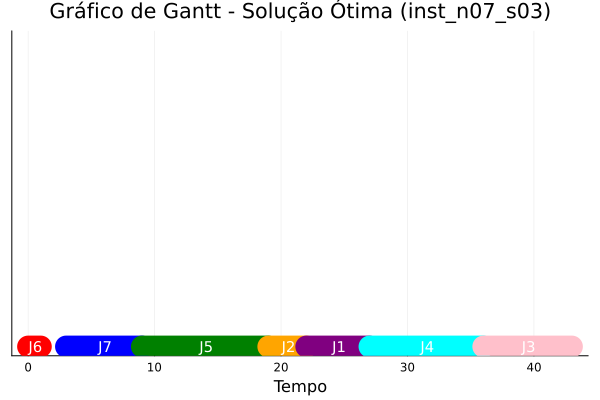

In [85]:
# =====================================================
# GERAÇÃO DO GRÁFICO DE GANTT (MILP)
# =====================================================
cores = [:red, :blue, :green, :orange, :purple, :cyan, :pink]

gantt = plot(
    legend = false,
    xlabel = "Tempo",
    ylabel = "",
    yticks = [],
    title = "Gráfico de Gantt - Solução Ótima (inst_n07_s03)"
)

for (k, j) in enumerate(ordem_otima)
    plot!(gantt,
        [inicio_milp[j], fim_milp[j]],
        [1, 1],
        lw = 22,
        color = cores[k]
    )
    annotate!(gantt, (
        (inicio_milp[j] + fim_milp[j]) / 2,
        1.0,
        text(jobs.Job[j], :white, :center, 10)
    ))
end

display(gantt)

INSTÂNCIA: inst_n09_s01 
=========================

In [70]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n09_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9"],
    r = [23, 4, 10, 11, 24, 13, 13, 2, 11],
    p = [5, 1, 2, 6, 10, 4, 10, 3,6],
    d = [33, 16, 20, 27, 40, 20, 33, 19, 22]
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
9×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         23      5     33
   2 │ J2          4      1     16
   3 │ J3         10      2     20
   4 │ J4         11      6     27
   5 │ J5         24     10     40
   6 │ J6         13      4     20
   7 │ J7         13     10     33
   8 │ J8          2      3     19
   9 │ J9         11      6     22



In [71]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [72]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [73]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 90 rows; 91 cols; 243 nonzeros; 81 integer variables (81 binary)
Coefficient ranges:
  Matrix  [1e+00, 7e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 7e+01]
Presolving model
81 rows, 46 cols, 234 nonzeros 0s
45 rows, 46 cols, 126 nonzeros 0s
45 rows, 46 cols, 126 nonzeros 0s
Presolve reductions: rows 45(-45); columns 46(-45); nonzeros 126(-117) 

Solving MIP model with:
   45 rows
   46 cols (36 binary, 0 integer, 0 implied int., 10 continuous, 0 domain fixed)
   126 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

In [74]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

7.692307692308825

In [78]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n09_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n09_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             13.0            1.05215e-12  25.2222
   2 │ SPT              27.0          107.692        29.2222
   3 │ EDD              14.0            7.69231      25.1111
   4 │ MILP             13.0            0.0          24.4444

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 12.999999999999863
MILO da Solução Ótima (MILP): 24.44


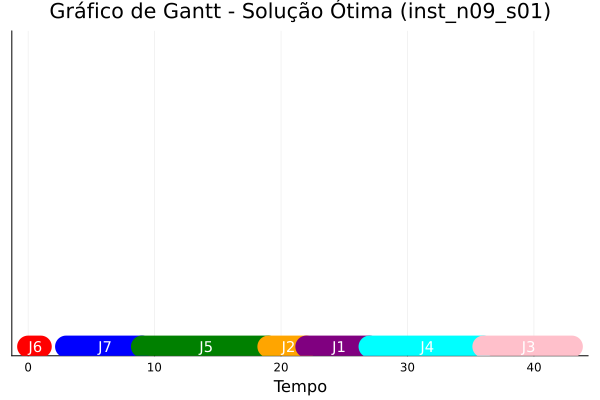

In [86]:
# =====================================================
# GERAÇÃO DO GRÁFICO DE GANTT (MILP)
# =====================================================
cores = [:red, :blue, :green, :orange, :purple, :cyan, :pink]

gantt = plot(
    legend = false,
    xlabel = "Tempo",
    ylabel = "",
    yticks = [],
    title = "Gráfico de Gantt - Solução Ótima (inst_n09_s01)"
)

for (k, j) in enumerate(ordem_otima)
    plot!(gantt,
        [inicio_milp[j], fim_milp[j]],
        [1, 1],
        lw = 22,
        color = cores[k]
    )
    annotate!(gantt, (
        (inicio_milp[j] + fim_milp[j]) / 2,
        1.0,
        text(jobs.Job[j], :white, :center, 10)
    ))
end

display(gantt)

INSTÂNCIA: inst_n09_s02
==================

In [2]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n09_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9"],
    r = [2, 5, 10, 4, 11, 9, 5, 1, 5],        # release (datas de liberação)
    p = [2, 3, 5, 5, 7, 7, 9, 2, 10],         # duration (tempos de processamento)
    d = [15, 22, 16, 22, 27, 22, 26, 7, 18],   # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
9×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          2      2     15
   2 │ J2          5      3     22
   3 │ J3         10      5     16
   4 │ J4          4      5     22
   5 │ J5         11      7     27
   6 │ J6          9      7     22
   7 │ J7          5      9     26
   8 │ J8          1      2      7
   9 │ J9          5     10     18



In [3]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [4]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [5]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 90 rows; 91 cols; 243 nonzeros; 81 integer variables (81 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 6e+01]
Presolving model
81 rows, 46 cols, 234 nonzeros 0s
45 rows, 46 cols, 126 nonzeros 0s
45 rows, 46 cols, 126 nonzeros 0s
Presolve reductions: rows 45(-45); columns 46(-45); nonzeros 126(-117) 

Solving MIP model with:
   45 rows
   46 cols (36 binary, 0 integer, 0 implied int., 10 continuous, 0 domain fixed)
   126 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

In [6]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

20.83333333334446

In [9]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n09_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n09_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             28.0                16.6667  24.3333
   2 │ SPT              35.0                45.8333  23.4444
   3 │ EDD              29.0                20.8333  28.2222
   4 │ MILP             24.0                 0.0     25.7778

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 23.99999999999779
MILO da Solução Ótima (MILP): 25.78


INSTÂNCIA: inst_n09_s03
========

In [12]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n09_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9"],
    r = [7, 6, 6, 17, 8, 15, 12, 11, 3],       # release (datas de liberação)
    p = [6, 2, 2, 4, 2, 3, 4, 2, 9],          # duration (tempos de processamento)
    d = [22, 14, 15, 31, 13, 24, 22, 14, 12],  # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
9×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          7      6     22
   2 │ J2          6      2     14
   3 │ J3          6      2     15
   4 │ J4         17      4     31
   5 │ J5          8      2     13
   6 │ J6         15      3     24
   7 │ J7         12      4     22
   8 │ J8         11      2     14
   9 │ J9          3      9     12



In [13]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [14]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [15]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 90 rows; 91 cols; 243 nonzeros; 81 integer variables (81 binary)
Coefficient ranges:
  Matrix  [1e+00, 5e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e+00, 5e+01]
Presolving model
81 rows, 46 cols, 234 nonzeros 0s
45 rows, 46 cols, 126 nonzeros 0s
45 rows, 46 cols, 126 nonzeros 0s
Presolve reductions: rows 45(-45); columns 46(-45); nonzeros 126(-117) 

Solving MIP model with:
   45 rows
   46 cols (36 binary, 0 integer, 0 implied int., 10 continuous, 0 domain fixed)
   126 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper

In [16]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

8.329139846966313e-12

In [17]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n09_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n09_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             12.0           33.3333       23.7778
   2 │ SPT              29.0          222.222        20.3333
   3 │ EDD               9.0            8.32914e-12  22.8889
   4 │ MILP              9.0            0.0          22.6667

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 8.99999999999925
MILO da Solução Ótima (MILP): 22.67


INSTÂNCIA: inst_n11_s01
===================

In [24]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n11_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11"],
    r = [6, 8, 16, 16, 3, 1, 5, 19, 0, 1, 19],         # release (datas de liberação)
    p = [7, 2, 1, 6, 3, 3, 1, 10, 1, 8, 3],             # duration (tempos de processamento)
    d = [25, 12, 20, 30, 17, 11, 11, 35, 3, 22, 32],    # due (prazos limites)
)

n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
11×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          6      7     25
   2 │ J2          8      2     12
   3 │ J3         16      1     20
   4 │ J4         16      6     30
   5 │ J5          3      3     17
   6 │ J6          1      3     11
   7 │ J7          5      1     11
   8 │ J8         19     10     35
   9 │ J9          0      1      3
  10 │ J10         1      8     22
  11 │ J11        19      3     32



In [25]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [26]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [27]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 132 rows; 133 cols; 363 nonzeros; 121 integer variables (121 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 6e+01]
Presolving model
121 rows, 67 cols, 352 nonzeros 0s
66 rows, 67 cols, 187 nonzeros 0s
66 rows, 67 cols, 187 nonzeros 0s
Presolve reductions: rows 66(-66); columns 67(-66); nonzeros 187(-176) 

Solving MIP model with:
   66 rows
   67 cols (55 binary, 0 integer, 0 implied int., 12 continuous, 0 domain fixed)
   187 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial 

In [28]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

60.00000000010976

In [30]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n11_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n11_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             13.0                   30.0  21.9091
   2 │ SPT              29.0                  190.0  31.5455
   3 │ EDD              16.0                   60.0  21.6364
   4 │ MILP             10.0                    0.0  20.7273

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 9.99999999999314
MILO da Solução Ótima (MILP): 20.73


INSTÂNCIA: inst_n11_s02 
=========================

In [31]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n11_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11"],
    r = [27, 15, 20, 30, 35, 34, 9, 17, 11, 31, 31],    # release (datas de liberação)
    p = [9, 3, 3, 8, 4, 8, 6, 8, 8, 4, 10],             # duration (tempos de processamento)
    d = [44, 39, 24, 38, 55, 63, 19, 26, 35, 44, 61],    # due (prazos limites)

)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
11×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         27      9     44
   2 │ J2         15      3     39
   3 │ J3         20      3     24
   4 │ J4         30      8     38
   5 │ J5         35      4     55
   6 │ J6         34      8     63
   7 │ J7          9      6     19
   8 │ J8         17      8     26
   9 │ J9         11      8     35
  10 │ J10        31      4     44
  11 │ J11        31     10     61



In [32]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [33]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [34]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 132 rows; 133 cols; 363 nonzeros; 121 integer variables (121 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [3e+00, 1e+02]
Presolving model
121 rows, 67 cols, 352 nonzeros 0s
66 rows, 67 cols, 187 nonzeros 0s
66 rows, 67 cols, 187 nonzeros 0s
Presolve reductions: rows 66(-66); columns 67(-66); nonzeros 187(-176) 

Solving MIP model with:
   66 rows
   67 cols (55 binary, 0 integer, 0 implied int., 12 continuous, 0 domain fixed)
   187 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial 

In [35]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

29.411764705937877

In [36]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n11_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n11_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             25.0                47.0588  47.0
   2 │ SPT              47.0               176.471   58.0
   3 │ EDD              22.0                29.4118  50.5455
   4 │ MILP             17.0                 0.0     46.0

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 16.999999999992706
MILO da Solução Ótima (MILP): 46.0


INSTÂNCIA: inst_n11_s03
=========================

In [37]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n11_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11"],
    r = [4, 14, 22, 14, 4, 17, 14, 16, 8, 26, 15],      # release (datas de liberação)
    p = [10, 8, 6, 3, 9, 4, 5, 7, 5, 10, 3],            # duration (tempos de processamento)
    d = [24, 32, 35, 18, 34, 32, 28, 26, 27, 41, 27],    # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
11×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          4     10     24
   2 │ J2         14      8     32
   3 │ J3         22      6     35
   4 │ J4         14      3     18
   5 │ J5          4      9     34
   6 │ J6         17      4     32
   7 │ J7         14      5     28
   8 │ J8         16      7     26
   9 │ J9          8      5     27
  10 │ J10        26     10     41
  11 │ J11        15      3     27



In [38]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [39]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [40]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 132 rows; 133 cols; 363 nonzeros; 121 integer variables (121 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [3e+00, 9e+01]
Presolving model
121 rows, 67 cols, 352 nonzeros 0s
66 rows, 67 cols, 187 nonzeros 0s
66 rows, 67 cols, 187 nonzeros 0s
Presolve reductions: rows 66(-66); columns 67(-66); nonzeros 187(-176) 

Solving MIP model with:
   66 rows
   67 cols (55 binary, 0 integer, 0 implied int., 12 continuous, 0 domain fixed)
   187 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial 

In [41]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

30.303188246289032

In [50]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n11_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n11_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             30.0                30.435   38.2308
   2 │ SPT              60.0               160.87    46.3846
   3 │ EDD              29.0                26.0872  42.2308
   4 │ MILP             23.0                 0.0     38.6923

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 22.999960001018426
MILO da Solução Ótima (MILP): 38.69


INSTÂNCIA: inst_n13_s01
==========

In [44]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n11_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13"],
    r = [13, 25, 11, 24, 14, 18, 18, 24, 28, 23, 12, 8, 10],              # release (datas de liberação)
    p = [10, 2, 2, 6, 2, 5, 1, 7, 8, 7, 3, 6, 2],                         # duration (tempos de processamento)
    d = [25, 35, 13, 43, 34, 24, 29, 43, 39, 46, 29, 29, 22],              # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
13×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         13     10     25
   2 │ J2         25      2     35
   3 │ J3         11      2     13
   4 │ J4         24      6     43
   5 │ J5         14      2     34
   6 │ J6         18      5     24
   7 │ J7         18      1     29
   8 │ J8         24      7     43
   9 │ J9         28      8     39
  10 │ J10        23      7     46
  11 │ J11        12      3     29
  12 │ J12         8      6     29
  13 │ J13        10      2     22



In [45]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [46]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [47]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 182 rows; 183 cols; 507 nonzeros; 169 integer variables (169 binary)
Coefficient ranges:
  Matrix  [1e+00, 9e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 9e+01]
Presolving model
169 rows, 92 cols, 494 nonzeros 0s
91 rows, 92 cols, 260 nonzeros 0s
91 rows, 92 cols, 260 nonzeros 0s
Presolve reductions: rows 91(-91); columns 92(-91); nonzeros 260(-247) 

Solving MIP model with:
   91 rows
   92 cols (78 binary, 0 integer, 0 implied int., 14 continuous, 0 domain fixed)
   260 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial 

In [48]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

26.087175798200935

In [49]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n13_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n13_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             30.0                30.435   38.2308
   2 │ SPT              60.0               160.87    46.3846
   3 │ EDD              29.0                26.0872  42.2308
   4 │ MILP             23.0                 0.0     38.6923

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 22.999960001018426
MILO da Solução Ótima (MILP): 38.69


INSTÂNCIA: inst_n13_s02
============================

In [7]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n13_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13"],
    r = [18, 35, 16, 22, 9, 32, 19, 10, 16, 14, 39, 35, 2],               # release (datas de liberação)
    p = [8, 10, 1, 5, 9, 1, 7, 8, 6, 10, 2, 3, 8],                         # duration (tempos de processamento)
    d = [31, 63, 23, 29, 32, 55, 31, 26, 23, 45, 44, 43, 32],              # due (prazos limites)

)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
13×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         18      8     31
   2 │ J2         35     10     63
   3 │ J3         16      1     23
   4 │ J4         22      5     29
   5 │ J5          9      9     32
   6 │ J6         32      1     55
   7 │ J7         19      7     31
   8 │ J8         10      8     26
   9 │ J9         16      6     23
  10 │ J10        14     10     45
  11 │ J11        39      2     44
  12 │ J12        35      3     43
  13 │ J13         2      8     32



In [8]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [9]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [10]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 182 rows; 183 cols; 507 nonzeros; 169 integer variables (169 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
169 rows, 92 cols, 494 nonzeros 0s
91 rows, 92 cols, 260 nonzeros 0s
91 rows, 92 cols, 260 nonzeros 0s
Presolve reductions: rows 91(-91); columns 92(-91); nonzeros 260(-247) 

Solving MIP model with:
   91 rows
   92 cols (78 binary, 0 integer, 0 implied int., 14 continuous, 0 domain fixed)
   260 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial 

In [12]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

58.33333333334608

In [14]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n13_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n13_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             36.0                50.0     49.8462
   2 │ SPT              70.0               191.667   65.3846
   3 │ EDD              38.0                58.3333  56.5385
   4 │ MILP             24.0                 0.0     44.9231

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 23.999999999998067
MILO da Solução Ótima (MILP): 44.92


INSTÂNCIA: inst_n13_s03
==========================

In [20]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n13_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13"],
     r = [22, 38, 5, 28, 21, 0, 3, 38, 21, 23, 38, 6, 20],                 # release (datas de liberação)
    p = [5, 9, 3, 10, 1, 7, 3, 5, 5, 10, 10, 3, 8],                        # duration (tempos de processamento)
    d = [41, 51, 10, 46, 23, 7, 28, 64, 37, 42, 61, 11, 28],               # due (prazos limites)

)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
13×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         22      5     41
   2 │ J2         38      9     51
   3 │ J3          5      3     10
   4 │ J4         28     10     46
   5 │ J5         21      1     23
   6 │ J6          0      7      7
   7 │ J7          3      3     28
   8 │ J8         38      5     64
   9 │ J9         21      5     37
  10 │ J10        23     10     42
  11 │ J11        38     10     61
  12 │ J12         6      3     11
  13 │ J13        20      8     28



In [21]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [17]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [22]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 182 rows; 183 cols; 507 nonzeros; 169 integer variables (169 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
169 rows, 92 cols, 494 nonzeros 0s
91 rows, 92 cols, 260 nonzeros 0s
91 rows, 92 cols, 260 nonzeros 0s
Presolve reductions: rows 91(-91); columns 92(-91); nonzeros 260(-247) 

Solving MIP model with:
   91 rows
   92 cols (78 binary, 0 integer, 0 implied int., 14 continuous, 0 domain fixed)
   260 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial 

In [23]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

100.0000105263165

In [25]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n13_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n13_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             36.0                89.4737  49.8462
   2 │ SPT              70.0               268.421   65.3846
   3 │ EDD              38.0               100.0     56.5385
   4 │ MILP             19.0                 0.0     40.1538

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 18.999998999999985
MILO da Solução Ótima (MILP): 40.15


INSTÂNCIA: inst_n15_s01
==================

In [27]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n15_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15"],
    r = [21, 10, 15, 23, 2, 23, 2, 11, 23, 6, 21, 18, 22, 10, 5],          # release (datas de liberação)
    p = [9, 9, 8, 4, 3, 3, 10, 4, 5, 4, 7, 6, 3, 1, 8],                  # duration (tempos de processamento)
    d = [35, 22, 29, 39, 13, 38, 20, 24, 42, 19, 44, 41, 41, 16, 24],      # due (prazos limites)

)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
15×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         21      9     35
   2 │ J2         10      9     22
   3 │ J3         15      8     29
   4 │ J4         23      4     39
   5 │ J5          2      3     13
   6 │ J6         23      3     38
   7 │ J7          2     10     20
   8 │ J8         11      4     24
   9 │ J9         23      5     42
  10 │ J10         6      4     19
  11 │ J11        21      7     44
  12 │ J12        18      6     41
  13 │ J13        22      3     41
  14 │ J14        10      1     16
  15 │ J15         5      8     24



In [28]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [29]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [30]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 240 rows; 241 cols; 675 nonzeros; 225 integer variables (225 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
225 rows, 121 cols, 660 nonzeros 0s
120 rows, 121 cols, 345 nonzeros 0s
120 rows, 121 cols, 345 nonzeros 0s
Presolve reductions: rows 120(-120); columns 121(-120); nonzeros 345(-330) 

Solving MIP model with:
   120 rows
   121 cols (105 binary, 0 integer, 0 implied int., 16 continuous, 0 domain fixed)
   345 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u

In [31]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

11.905039000295774

In [39]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n15_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n15_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             29.0           61.1113       53.2
   2 │ SPT              82.0          355.556        72.8667
   3 │ EDD              18.0            0.000146914  50.2667
   4 │ MILP             18.0            0.0          50.2667

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 17.99997355555712
MILO da Solução Ótima (MILP): 50.27


INSTÂNCIA: inst_n15_s02
=======================

In [34]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n15_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15"],
    r = [18, 5, 22, 43, 27, 43, 6, 17, 41, 38, 12, 14, 18, 41, 43],        # release (datas de liberação)
    p = [8, 10, 5, 2, 5, 2, 9, 10, 2, 3, 3, 2, 4, 10, 5],                  # duration (tempos de processamento)
    d = [39, 21, 38, 54, 51, 62, 23, 39, 56, 52, 22, 24, 31, 67, 56],      # due (prazos limites)

)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
15×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         18      8     39
   2 │ J2          5     10     21
   3 │ J3         22      5     38
   4 │ J4         43      2     54
   5 │ J5         27      5     51
   6 │ J6         43      2     62
   7 │ J7          6      9     23
   8 │ J8         17     10     39
   9 │ J9         41      2     56
  10 │ J10        38      3     52
  11 │ J11        12      3     22
  12 │ J12        14      2     24
  13 │ J13        18      4     31
  14 │ J14        41     10     67
  15 │ J15        43      5     56



In [35]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [36]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [37]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 240 rows; 241 cols; 675 nonzeros; 225 integer variables (225 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e+00, 1e+02]
Presolving model
225 rows, 121 cols, 660 nonzeros 0s
120 rows, 121 cols, 345 nonzeros 0s
120 rows, 121 cols, 345 nonzeros 0s
Presolve reductions: rows 120(-120); columns 121(-120); nonzeros 345(-330) 

Solving MIP model with:
   120 rows
   121 cols (105 binary, 0 integer, 0 implied int., 16 continuous, 0 domain fixed)
   345 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u

In [38]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

0.00014691378739630298

In [40]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n15_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n15_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             29.0           61.1113       53.2
   2 │ SPT              82.0          355.556        72.8667
   3 │ EDD              18.0            0.000146914  50.2667
   4 │ MILP             18.0            0.0          50.2667

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 17.99997355555712
MILO da Solução Ótima (MILP): 50.27


 INSTÂNCIA: inst_n15_s03
================

In [41]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n15_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15"],
    r = [4, 2, 0, 0, 11, 9, 7, 10, 2, 17, 7, 20, 20, 1, 10],               # release (datas de liberação)
    p = [2, 10, 9, 2, 9, 1, 9, 3, 6, 4, 9, 2, 1, 6, 8],                    # duration (tempos de processamento)
    d = [13, 22, 17, 12, 36, 16, 28, 24, 19, 37, 26, 38, 30, 16, 30],      # due (prazos limites)

)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
15×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          4      2     13
   2 │ J2          2     10     22
   3 │ J3          0      9     17
   4 │ J4          0      2     12
   5 │ J5         11      9     36
   6 │ J6          9      1     16
   7 │ J7          7      9     28
   8 │ J8         10      3     24
   9 │ J9          2      6     19
  10 │ J10        17      4     37
  11 │ J11         7      9     26
  12 │ J12        20      2     38
  13 │ J13        20      1     30
  14 │ J14         1      6     16
  15 │ J15        10      8     30



In [42]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [43]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [44]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 240 rows; 241 cols; 675 nonzeros; 225 integer variables (225 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
225 rows, 121 cols, 660 nonzeros 0s
120 rows, 121 cols, 345 nonzeros 0s
120 rows, 121 cols, 345 nonzeros 0s
Presolve reductions: rows 120(-120); columns 121(-120); nonzeros 345(-330) 

Solving MIP model with:
   120 rows
   121 cols (105 binary, 0 integer, 0 implied int., 16 continuous, 0 domain fixed)
   345 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u

In [45]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

11.628161382514575

In [47]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n15_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n15_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          51.0                   18.6049  47.8667
   2 │ SPT           78.0                   81.3958  47.7333
   3 │ EDD           48.0                   11.6282  44.9333
   4 │ MILP          42.9999                 0.0     46.4667

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 42.99990200100054
MILO da Solução Ótima (MILP): 46.47


INSTÂNCIA: inst_n17_s01
===============

In [49]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n17_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17"],
    r = [18, 16, 31, 23, 15, 20, 3, 20, 18, 18, 6, 30, 25, 2, 1, 4, 13],   # release (datas de liberação)
    p = [6, 4, 4, 10, 5, 2, 3, 10, 10, 7, 7, 7, 9, 9, 8, 4, 1],            # duration (tempos de processamento)
    d = [44, 27, 49, 46, 30, 38, 16, 50, 48, 38, 25, 52, 54, 28, 21, 15, 22], # due (prazos limites)

)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
17×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         18      6     44
   2 │ J2         16      4     27
   3 │ J3         31      4     49
   4 │ J4         23     10     46
   5 │ J5         15      5     30
   6 │ J6         20      2     38
   7 │ J7          3      3     16
   8 │ J8         20     10     50
   9 │ J9         18     10     48
  10 │ J10        18      7     38
  11 │ J11         6      7     25
  12 │ J12        30      7     52
  13 │ J13        25      9     54
  14 │ J14         2      9     28
  15 │ J15         1      8     21
  16 │ J16         4      4     15
  17 │ J17        13      1     22



In [50]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [51]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [52]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 306 rows; 307 cols; 867 nonzeros; 289 integer variables (289 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
289 rows, 154 cols, 850 nonzeros 0s
153 rows, 154 cols, 442 nonzeros 0s
153 rows, 154 cols, 442 nonzeros 0s
Presolve reductions: rows 153(-153); columns 154(-153); nonzeros 442(-425) 

Solving MIP model with:
   153 rows
   154 cols (136 binary, 0 integer, 0 implied int., 18 continuous, 0 domain fixed)
   442 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u

In [53]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

5.660644498503855

In [55]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n17_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n17_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          58.0                   9.43424  54.4706
   2 │ SPT           79.0                  49.057    62.6471
   3 │ EDD           56.0                   5.66064  53.0
   4 │ MILP          52.9999                0.0      53.5294

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 52.99986600099998
MILO da Solução Ótima (MILP): 53.53


INSTÂNCIA: inst_n17_s02 
==================

In [56]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n17_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17"],
    r = [29, 24, 14, 23, 2, 34, 17, 1, 28, 28, 32, 14, 23, 25, 29, 5, 12], # release (datas de liberação)
    p = [8, 5, 1, 10, 5, 4, 9, 4, 8, 7, 8, 5, 5, 8, 7, 3, 10],             # duration (tempos de processamento)
    d = [54, 45, 26, 52, 23, 50, 39, 11, 49, 54, 53, 29, 46, 43, 58, 22, 32], # due (prazos limites)
    
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()




--- DADOS DA INSTÂNCIA ---
17×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         29      8     54
   2 │ J2         24      5     45
   3 │ J3         14      1     26
   4 │ J4         23     10     52
   5 │ J5          2      5     23
   6 │ J6         34      4     50
   7 │ J7         17      9     39
   8 │ J8          1      4     11
   9 │ J9         28      8     49
  10 │ J10        28      7     54
  11 │ J11        32      8     53
  12 │ J12        14      5     29
  13 │ J13        23      5     46
  14 │ J14        25      8     43
  15 │ J15        29      7     58
  16 │ J16         5      3     22
  17 │ J17        12     10     32



In [57]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [58]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [59]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 306 rows; 307 cols; 867 nonzeros; 289 integer variables (289 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
289 rows, 154 cols, 850 nonzeros 0s
153 rows, 154 cols, 442 nonzeros 0s
153 rows, 154 cols, 442 nonzeros 0s
Presolve reductions: rows 153(-153); columns 154(-153); nonzeros 442(-425) 

Solving MIP model with:
   153 rows
   154 cols (136 binary, 0 integer, 0 implied int., 18 continuous, 0 domain fixed)
   442 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u

In [60]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

2.0002692786706815

In [62]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n17_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n17_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          58.0                  16.0003   54.0588
   2 │ SPT          105.0                 110.001    73.0
   3 │ EDD           51.0                   2.00027  52.4706
   4 │ MILP          49.9999                0.0      54.4706

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 49.9998680010001
MILO da Solução Ótima (MILP): 54.47


INSTÂNCIA: inst_n17_s03
=======================



In [64]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n17_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17"],
    r = [21, 24, 6, 17, 8, 5, 1, 23, 8, 11, 0, 12, 1, 22, 2, 10, 19],     # release (datas de liberação)
    p = [7, 1, 9, 3, 8, 2, 7, 8, 7, 1, 5, 1, 2, 8, 7, 8, 9],               # duration (tempos de processamento)
    d = [45, 34, 30, 33, 26, 17, 18, 48, 28, 25, 13, 26, 16, 44, 23, 31, 41], # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()



--- DADOS DA INSTÂNCIA ---
17×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         21      7     45
   2 │ J2         24      1     34
   3 │ J3          6      9     30
   4 │ J4         17      3     33
   5 │ J5          8      8     26
   6 │ J6          5      2     17
   7 │ J7          1      7     18
   8 │ J8         23      8     48
   9 │ J9          8      7     28
  10 │ J10        11      1     25
  11 │ J11         0      5     13
  12 │ J12        12      1     26
  13 │ J13         1      2     16
  14 │ J14        22      8     44
  15 │ J15         2      7     23
  16 │ J16        10      8     31
  17 │ J17        19      9     41



In [65]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [66]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [67]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 306 rows; 307 cols; 867 nonzeros; 289 integer variables (289 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
289 rows, 154 cols, 850 nonzeros 0s
153 rows, 154 cols, 442 nonzeros 0s
153 rows, 154 cols, 442 nonzeros 0s
Presolve reductions: rows 153(-153); columns 154(-153); nonzeros 442(-425) 

Solving MIP model with:
   153 rows
   154 cols (136 binary, 0 integer, 0 implied int., 18 continuous, 0 domain fixed)
   442 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u

In [68]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

5.1108914778226265e-5

In [69]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n17_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n17_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             59.0            31.1112      49.1765
   2 │ SPT              78.0            73.3334      59.4118
   3 │ EDD              45.0             5.11089e-5  43.6471
   4 │ MILP             45.0             0.0         43.8824

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 44.999977001000104
MILO da Solução Ótima (MILP): 43.88


INSTÂNCIA: inst_n19_s01
==================

In [77]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n19_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19"],
    r = [29, 39, 21, 25, 4, 18, 30, 24, 11, 23, 23, 10, 44, 30, 16, 20, 28, 22, 6], # release (datas de liberação)
    p = [9, 3, 7, 7, 3, 5, 8, 5, 8, 4, 10, 9, 2, 8, 9, 6, 6, 1, 7],                  # duration (tempos de processamento)
    d = [54, 53, 44, 43, 23, 38, 52, 45, 35, 39, 48, 22, 54, 50, 39, 41, 49, 31, 25], # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()



--- DADOS DA INSTÂNCIA ---
19×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         29      9     54
   2 │ J2         39      3     53
   3 │ J3         21      7     44
   4 │ J4         25      7     43
   5 │ J5          4      3     23
   6 │ J6         18      5     38
   7 │ J7         30      8     52
   8 │ J8         24      5     45
   9 │ J9         11      8     35
  10 │ J10        23      4     39
  11 │ J11        23     10     48
  12 │ J12        10      9     22
  13 │ J13        44      2     54
  14 │ J14        30      8     50
  15 │ J15        16      9     39
  16 │ J16        20      6     41
  17 │ J17        28      6     49
  18 │ J18        22      1     31
  19 │ J19         6      7     25



In [78]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [79]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [80]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 380 rows; 381 cols; 1083 nonzeros; 361 integer variables (361 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+02]
Presolving model
361 rows, 191 cols, 1064 nonzeros 0s
190 rows, 191 cols, 551 nonzeros 0s
190 rows, 191 cols, 551 nonzeros 0s
Presolve reductions: rows 190(-190); columns 191(-190); nonzeros 551(-532) 

Solving MIP model with:
   190 rows
   191 cols (171 binary, 0 integer, 0 implied int., 20 continuous, 0 domain fixed)
   551 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [81]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

8.955479192556334

In [82]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n19_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n19_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          67.0               0.000234327  67.4737
   2 │ SPT          119.0              77.6124       89.8421
   3 │ EDD           73.0               8.95548      70.8421
   4 │ MILP          66.9998            0.0          64.1053

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 66.99984300100003
MILO da Solução Ótima (MILP): 64.11


INSTÂNCIA: inst_n19_s02
========================

In [83]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n19_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19"],
    r = [29, 39, 21, 25, 4, 18, 30, 24, 11, 23, 23, 10, 44, 30, 16, 20, 28, 22, 6], # release (datas de liberação)
    p = [9, 3, 7, 7, 3, 5, 8, 5, 8, 4, 10, 9, 2, 8, 9, 6, 6, 1, 7],                  # duration (tempos de processamento)
    d = [54, 53, 44, 43, 23, 38, 52, 45, 35, 39, 48, 22, 54, 50, 39, 41, 49, 31, 25], # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()


--- DADOS DA INSTÂNCIA ---
19×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         29      9     54
   2 │ J2         39      3     53
   3 │ J3         21      7     44
   4 │ J4         25      7     43
   5 │ J5          4      3     23
   6 │ J6         18      5     38
   7 │ J7         30      8     52
   8 │ J8         24      5     45
   9 │ J9         11      8     35
  10 │ J10        23      4     39
  11 │ J11        23     10     48
  12 │ J12        10      9     22
  13 │ J13        44      2     54
  14 │ J14        30      8     50
  15 │ J15        16      9     39
  16 │ J16        20      6     41
  17 │ J17        28      6     49
  18 │ J18        22      1     31
  19 │ J19         6      7     25



In [84]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [85]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [86]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 380 rows; 381 cols; 1083 nonzeros; 361 integer variables (361 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+02]
Presolving model
361 rows, 191 cols, 1064 nonzeros 0s
190 rows, 191 cols, 551 nonzeros 0s
190 rows, 191 cols, 551 nonzeros 0s
Presolve reductions: rows 190(-190); columns 191(-190); nonzeros 551(-532) 

Solving MIP model with:
   190 rows
   191 cols (171 binary, 0 integer, 0 implied int., 20 continuous, 0 domain fixed)
   551 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [87]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

8.955479192556334

In [88]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n19_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n19_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          67.0               0.000234327  67.4737
   2 │ SPT          119.0              77.6124       89.8421
   3 │ EDD           73.0               8.95548      70.8421
   4 │ MILP          66.9998            0.0          64.1053

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 66.99984300100003
MILO da Solução Ótima (MILP): 64.11


INSTÂNCIA: inst_n19_s03
=====================

In [89]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n19_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19"],
    r = [2, 10, 11, 20, 1, 15, 0, 7, 10, 4, 17, 7, 20, 2, 0, 26, 9, 8, 14],       # release (datas de liberação)
    p = [6, 3, 9, 2, 6, 3, 9, 9, 8, 2, 4, 9, 1, 10, 2, 10, 1, 5, 5],               # duration (tempos de processamento)
    d = [19, 24, 36, 38, 16, 27, 17, 28, 30, 13, 37, 26, 30, 22, 12, 41, 16, 27, 28], # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
19×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          2      6     19
   2 │ J2         10      3     24
   3 │ J3         11      9     36
   4 │ J4         20      2     38
   5 │ J5          1      6     16
   6 │ J6         15      3     27
   7 │ J7          0      9     17
   8 │ J8          7      9     28
   9 │ J9         10      8     30
  10 │ J10         4      2     13
  11 │ J11        17      4     37
  12 │ J12         7      9     26
  13 │ J13        20      1     30
  14 │ J14         2     10     22
  15 │ J15         0      2     12
  16 │ J16        26     10     41
  17 │ J17         9      1     16
  18 │ J18         8      5     27
  19 │ J19        14      5     28



In [90]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [94]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [92]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 380 rows; 381 cols; 1083 nonzeros; 361 integer variables (361 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
361 rows, 191 cols, 1064 nonzeros 0s
190 rows, 191 cols, 551 nonzeros 0s
190 rows, 191 cols, 551 nonzeros 0s
Presolve reductions: rows 190(-190); columns 191(-190); nonzeros 551(-532) 

Solving MIP model with:
   190 rows
   191 cols (171 binary, 0 integer, 0 implied int., 20 continuous, 0 domain fixed)
   551 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [93]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

3.1748013340916357

In [96]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n19_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n19_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          64.0                    1.5875  58.2105
   2 │ SPT           92.0                   46.032   57.7368
   3 │ EDD           65.0                    3.1748  53.1053
   4 │ MILP          62.9999                 0.0     50.7895

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 62.99987900100013
MILO da Solução Ótima (MILP): 50.79


INSTÂNCIA: inst_n21_s01
=================

In [97]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n21_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19", "J20","J21"],
    r = [26, 44, 43, 6, 41, 14, 14, 18, 38, 27, 43, 2, 41, 18, 43, 35, 17, 22, 5, 12, 16], # release (datas de liberação)
    p = [5, 2, 5, 9, 10, 2, 5, 4, 3, 5, 2, 8, 2, 8, 5, 10, 10, 5, 10, 3, 5],              # duration (tempos de processamento)
    d = [39, 54, 56, 23, 67, 24, 31, 31, 52, 51, 62, 32, 56, 39, 56, 63, 39, 38, 21, 22, 28], # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
21×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         26      5     39
   2 │ J2         44      2     54
   3 │ J3         43      5     56
   4 │ J4          6      9     23
   5 │ J5         41     10     67
   6 │ J6         14      2     24
   7 │ J7         14      5     31
   8 │ J8         18      4     31
   9 │ J9         38      3     52
  10 │ J10        27      5     51
  11 │ J11        43      2     62
  12 │ J12         2      8     32
  13 │ J13        41      2     56
  14 │ J14        18      8     39
  15 │ J15        43      5     56
  16 │ J16        35     10     63
  17 │ J17        17     10     39
  18 │ J18        22      5     38
  19 │ J19         5     10     21
  20 │ J20        12      3     22
  21 │ J21        16      5     28



In [98]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [99]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [100]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 462 rows; 463 cols; 1323 nonzeros; 441 integer variables (441 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e+00, 2e+02]
Presolving model
441 rows, 232 cols, 1302 nonzeros 0s
231 rows, 232 cols, 672 nonzeros 0s
231 rows, 232 cols, 672 nonzeros 0s
Presolve reductions: rows 231(-231); columns 232(-231); nonzeros 672(-651) 

Solving MIP model with:
   231 rows
   232 cols (210 binary, 0 integer, 0 implied int., 22 continuous, 0 domain fixed)
   672 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [101]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

5.660680383353881

In [102]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n21_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n21_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          66.0                  24.5287   70.0476
   2 │ SPT          141.0                 166.038    89.1905
   3 │ EDD           56.0                   5.66068  67.1905
   4 │ MILP          52.9998                0.0      65.7619

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 52.99984800100002
MILO da Solução Ótima (MILP): 65.76


INSTÂNCIA: inst_n21_s02
========================

In [103]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n21_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19", "J20","J21"],
    r = [14, 17, 24, 25, 22, 19, 33, 1, 2, 27, 21, 11, 23, 23, 10, 44, 30, 16, 20, 28, 6], # release (datas de liberação)
    p = [9, 8, 10, 3, 4, 9, 7, 7, 3, 5, 8, 5, 8, 4, 10, 9, 2, 8, 9, 6, 7],                  # duration (tempos de processamento)
    d = [27, 39, 53, 54, 35, 39, 52, 13, 23, 38, 52, 45, 35, 39, 48, 22, 54, 50, 39, 41, 25], # due (prazos limites)
)
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
21×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         14      9     27
   2 │ J2         17      8     39
   3 │ J3         24     10     53
   4 │ J4         25      3     54
   5 │ J5         22      4     35
   6 │ J6         19      9     39
   7 │ J7         33      7     52
   8 │ J8          1      7     13
   9 │ J9          2      3     23
  10 │ J10        27      5     38
  11 │ J11        21      8     52
  12 │ J12        11      5     45
  13 │ J13        23      8     35
  14 │ J14        23      4     39
  15 │ J15        10     10     48
  16 │ J16        44      9     22
  17 │ J17        30      2     54
  18 │ J18        16      8     50
  19 │ J19        20      9     39
  20 │ J20        28      6     41
  21 │ J21         6      7     25



In [104]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [105]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [106]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 462 rows; 463 cols; 1323 nonzeros; 441 integer variables (441 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+02]
Presolving model
441 rows, 232 cols, 1302 nonzeros 0s
231 rows, 232 cols, 672 nonzeros 0s
231 rows, 232 cols, 672 nonzeros 0s
Presolve reductions: rows 231(-231); columns 232(-231); nonzeros 672(-651) 

Solving MIP model with:
   231 rows
   232 cols (210 binary, 0 integer, 0 implied int., 22 continuous, 0 domain fixed)
   672 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [107]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

40.90937592525574

In [109]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n21_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n21_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO     
     │ String  Float64        Float64                Float64  
─────┼────────────────────────────────────────────────────────
   1 │ FIFO         120.0                   36.3639   77.381
   2 │ SPT          123.0                   39.773    89.7143
   3 │ EDD          124.0                   40.9094  110.524
   4 │ MILP          87.9998                 0.0      76.4762

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 87.99982200316806
MILO da Solução Ótima (MILP): 76.48


INSTÂNCIA: inst_n21_s03 
========================

In [117]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n21_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19", "J20","J21"],
    r = [2, 10, 11, 20, 1, 15, 0, 7, 10, 4, 17, 7, 20, 2, 0, 26, 9, 8, 14, 21, 22],       # release (datas de liberação)
    p = [6, 3, 9, 2, 6, 3, 9, 9, 8, 2, 4, 9, 1, 10, 2, 10, 1, 5, 5, 9, 3],                  # duration (tempos de processamento)
    d = [19, 24, 36, 38, 16, 27, 17, 28, 30, 13, 37, 26, 30, 22, 12, 41, 16, 27, 28, 43, 37], # due (prazos limites)

    )
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
21×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          2      6     19
   2 │ J2         10      3     24
   3 │ J3         11      9     36
   4 │ J4         20      2     38
   5 │ J5          1      6     16
   6 │ J6         15      3     27
   7 │ J7          0      9     17
   8 │ J8          7      9     28
   9 │ J9         10      8     30
  10 │ J10         4      2     13
  11 │ J11        17      4     37
  12 │ J12         7      9     26
  13 │ J13        20      1     30
  14 │ J14         2     10     22
  15 │ J15         0      2     12
  16 │ J16        26     10     41
  17 │ J17         9      1     16
  18 │ J18         8      5     27
  19 │ J19        14      5     28
  20 │ J20        21      9     43
  21 │ J21        22      3     37



In [111]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [112]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [113]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 462 rows; 463 cols; 1323 nonzeros; 441 integer variables (441 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
441 rows, 232 cols, 1302 nonzeros 0s
231 rows, 232 cols, 672 nonzeros 0s
231 rows, 232 cols, 672 nonzeros 0s
Presolve reductions: rows 231(-231); columns 232(-231); nonzeros 672(-651) 

Solving MIP model with:
   231 rows
   232 cols (210 binary, 0 integer, 0 implied int., 22 continuous, 0 domain fixed)
   672 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [114]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

2.7399174318632076

In [116]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n21_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n21_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          75.0                   2.73992  63.1905
   2 │ SPT          104.0                  42.466    62.0952
   3 │ EDD           75.0                   2.73992  58.5714
   4 │ MILP          72.9999                0.0      57.619

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 72.99986400100016
MILO da Solução Ótima (MILP): 57.62


INSTÂNCIA: inst_n23_s01
===================

In [119]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n23_s01)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19", "J20","J21","J22", "J23"],
    r = [29, 39, 21, 25, 4, 18, 30, 24, 11, 23, 23, 10, 44, 30, 16, 20, 28, 22, 6, 26, 44, 43, 6], # release (datas de liberação)
    p = [9, 3, 7, 7, 3, 5, 8, 5, 8, 4, 10, 9, 2, 8, 9, 6, 6, 1, 7, 5, 2, 5, 9],                  # duration (tempos de processamento)
    d = [54, 53, 44, 43, 23, 38, 52, 45, 35, 39, 48, 22, 54, 50, 39, 41, 49, 31, 25, 39, 54, 56, 23], # due (prazos limites)
    )
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
23×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         29      9     54
   2 │ J2         39      3     53
   3 │ J3         21      7     44
   4 │ J4         25      7     43
   5 │ J5          4      3     23
   6 │ J6         18      5     38
   7 │ J7         30      8     52
   8 │ J8         24      5     45
   9 │ J9         11      8     35
  10 │ J10        23      4     39
  11 │ J11        23     10     48
  12 │ J12        10      9     22
  13 │ J13        44      2     54
  14 │ J14        30      8     50
  15 │ J15        16      9     39
  16 │ J16        20      6     41
  17 │ J17        28      6     49
  18 │ J18        22      1     31
  19 │ J19         6      7     25
  20 │ J20        26      5     39
  21 │ J21        44      2     54
  22 │ J22        43      5     56
  23 │ J23         6      9     23



In [120]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [121]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [122]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 552 rows; 553 cols; 1587 nonzeros; 529 integer variables (529 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+02]
Presolving model
529 rows, 277 cols, 1564 nonzeros 0s
276 rows, 277 cols, 805 nonzeros 0s
276 rows, 277 cols, 805 nonzeros 0s
Presolve reductions: rows 276(-276); columns 277(-276); nonzeros 805(-782) 

Solving MIP model with:
   276 rows
   277 cols (253 binary, 0 integer, 0 implied int., 24 continuous, 0 domain fixed)
   805 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [123]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

6.976745430049337

In [124]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n23_s01 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n23_s01 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO             88.0                2.32558  81.3913
   2 │ SPT             148.0               72.093    97.3913
   3 │ EDD              92.0                6.97675  84.6087
   4 │ MILP             86.0                0.0      78.0435

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 85.99999899992991
MILO da Solução Ótima (MILP): 78.04


INSTÂNCIA: inst_n23_s02 
==========================

In [125]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n23_s02)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19", "J20","J21","J22", "J23"],
    r = [14, 14, 18, 38, 27, 43, 2, 41, 18, 43, 35, 17, 22, 5, 12, 14, 17, 24, 25, 22, 19, 33, 1], # release (datas de liberação)
    p = [2, 5, 4, 3, 5, 2, 8, 2, 8, 5, 10, 10, 5, 10, 3, 9, 8, 10, 3, 4, 9, 7, 7],                  # duration (tempos de processamento)
    d = [24, 31, 31, 52, 51, 62, 32, 56, 39, 56, 63, 39, 38, 21, 22, 27, 39, 53, 54, 35, 39, 52, 13], # due (prazos limites)
    )
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
23×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1         14      2     24
   2 │ J2         14      5     31
   3 │ J3         18      4     31
   4 │ J4         38      3     52
   5 │ J5         27      5     51
   6 │ J6         43      2     62
   7 │ J7          2      8     32
   8 │ J8         41      2     56
   9 │ J9         18      8     39
  10 │ J10        43      5     56
  11 │ J11        35     10     63
  12 │ J12        17     10     39
  13 │ J13        22      5     38
  14 │ J14         5     10     21
  15 │ J15        12      3     22
  16 │ J16        14      9     27
  17 │ J17        17      8     39
  18 │ J18        24     10     53
  19 │ J19        25      3     54
  20 │ J20        22      4     35
  21 │ J21        19      9     39
  22 │ J22        33      7     52
  23 │ J23         1      7     13



In [126]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [127]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [128]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 552 rows; 553 cols; 1587 nonzeros; 529 integer variables (529 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+02]
Presolving model
529 rows, 277 cols, 1564 nonzeros 0s
276 rows, 277 cols, 805 nonzeros 0s
276 rows, 277 cols, 805 nonzeros 0s
Presolve reductions: rows 276(-276); columns 277(-276); nonzeros 805(-782) 

Solving MIP model with:
   276 rows
   277 cols (253 binary, 0 integer, 0 implied int., 24 continuous, 0 domain fixed)
   805 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [129]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

7.548577125593669e-5

In [130]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n23_s02 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n23_s02 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO          84.0                9.09099     79.2174
   2 │ SPT          149.0               93.5066      93.8696
   3 │ EDD           77.0                7.54858e-5  75.0435
   4 │ MILP          76.9999             0.0         78.4348

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 76.99994187600001
MILO da Solução Ótima (MILP): 78.43


INSTÂNCIA: inst_n23_s03
=====================

In [132]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_n23_s03)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9","J10","J11","J12","J13","J14","J15", "J16","J17", "J18", "J19", "J20","J21","J22", "J23"],
    r = [2, 27, 21, 11, 23, 23, 10, 44, 30, 16, 20, 28, 6, 2, 10, 11, 20, 1, 15, 0, 7, 10, 4],       # release (datas de liberação)
    p = [3, 5, 8, 5, 8, 4, 10, 9, 2, 8, 9, 6, 7, 6, 3, 9, 2, 6, 3, 9, 9, 8, 2],                  # duration (tempos de processamento)
    d = [23, 38, 52, 45, 35, 39, 48, 22, 54, 50, 39, 41, 25, 19, 24, 36, 38, 16, 27, 17, 28, 30, 13], # due (prazos limites)
    )
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
23×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          2      3     23
   2 │ J2         27      5     38
   3 │ J3         21      8     52
   4 │ J4         11      5     45
   5 │ J5         23      8     35
   6 │ J6         23      4     39
   7 │ J7         10     10     48
   8 │ J8         44      9     22
   9 │ J9         30      2     54
  10 │ J10        16      8     50
  11 │ J11        20      9     39
  12 │ J12        28      6     41
  13 │ J13         6      7     25
  14 │ J14         2      6     19
  15 │ J15        10      3     24
  16 │ J16        11      9     36
  17 │ J17        20      2     38
  18 │ J18         1      6     16
  19 │ J19        15      3     27
  20 │ J20         0      9     17
  21 │ J21         7      9     28
  22 │ J22        10      8     30
  23 │ J23         4      2     13



In [133]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [134]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"EDD"

In [135]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 552 rows; 553 cols; 1587 nonzeros; 529 integer variables (529 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+02]
Presolving model
529 rows, 277 cols, 1564 nonzeros 0s
276 rows, 277 cols, 805 nonzeros 0s
276 rows, 277 cols, 805 nonzeros 0s
Presolve reductions: rows 276(-276); columns 277(-276); nonzeros 805(-782) 

Solving MIP model with:
   276 rows
   277 cols (253 binary, 0 integer, 0 implied int., 24 continuous, 0 domain fixed)
   805 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [136]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

24.13793246136781

In [137]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_n23_s03 (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_n23_s03 (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO            119.0                36.7816  74.5217
   2 │ SPT             135.0                55.1724  86.4783
   3 │ EDD             108.0                24.1379  89.8261
   4 │ MILP             87.0                 0.0     72.1739

Melhor Regra Heurística (pelo Atraso Máximo): EDD
Atraso Máximo Ótimo (MILP): 86.9999989999914
MILO da Solução Ótima (MILP): 72.17


INSTÂNCIA: inst_book 
===============

In [138]:
using JuMP
using HiGHS
using DataFrames
using Printf
using Plots

# =====================================================
# CONFIGURAÇÃO DA INSTÂNCIA (inst_book)
# =====================================================
jobs = DataFrame(
    Job = ["J1", "J2", "J3", "J4", "J5", "J6", "J7"],
    r = [2, 5, 1, 4, 7, 3, 4],       # release (datas de liberação)
    p = [3, 2, 2, 1, 4, 4, 3],       # duration (tempos de processamento)
    d = [6, 9, 8, 5, 12, 10, 9],     # due (prazos limites)
    )
n = nrow(jobs)

println("--- DADOS DA INSTÂNCIA ---")
println(jobs)
println()

--- DADOS DA INSTÂNCIA ---
7×4 DataFrame
 Row │ Job     r      p      d     
     │ String  Int64  Int64  Int64 
─────┼─────────────────────────────
   1 │ J1          2      3      6
   2 │ J2          5      2      9
   3 │ J3          1      2      8
   4 │ J4          4      1      5
   5 │ J5          7      4     12
   6 │ J6          3      4     10
   7 │ J7          4      3      9



In [139]:
# =====================================================
# FUNÇÃO DE AVALIAÇÃO DE REGRAS HEURÍSTICAS (Com MILO)
# =====================================================
function avaliar(ordem)
    tempo = 0
    inicio = zeros(Int, n)
    fim = zeros(Int, n)
    atraso = zeros(Int, n)
    
    for job in ordem
        tempo = max(tempo, jobs.r[job])
        inicio[job] = tempo
        tempo += jobs.p[job]
        fim[job] = tempo
        atraso[job] = max(0, fim[job] - jobs.d[job])
    end
    
    atraso_max = maximum(atraso)
    milo = sum(fim) / n  # Cálculo do MILO (Média dos Instantes de Término)
    
    return atraso_max, milo, inicio, fim
end

avaliar (generic function with 1 method)

In [140]:
# =====================================================
# EXECUÇÃO DAS HEURÍSTICAS
# =====================================================
# 1. FIFO (Ordem de Chegada / r)
fifo = sortperm(jobs.r)
obj_fifo, milo_fifo, inicio_fifo, fim_fifo = avaliar(fifo)

# 2. SPT (Menor Tempo de Processamento / p)
spt = sortperm(jobs.p)
obj_spt, milo_spt, inicio_spt, fim_spt = avaliar(spt)

# 3. EDD (Data Limite Mais Próxima / d)
edd = sortperm(jobs.d)
obj_edd, milo_edd, inicio_edd, fim_edd = avaliar(edd)

# Seleção da Melhor Regra Heurística (Baseado no objetivo principal: Atraso Máximo)
nomes_regras = ["FIFO", "SPT", "EDD"]
valores_regras = [obj_fifo, obj_spt, obj_edd]
indice_melhor = argmin(valores_regras)
melhor_regra = nomes_regras[indice_melhor]

"FIFO"

In [141]:
# =====================================================
# MODELO MATEMÁTICO (MILP)
# =====================================================
modelo = Model(HiGHS.Optimizer)

# Configuração das tolerâncias e parâmetros do solver ANTES do optimize!
set_attribute(modelo, "mip_rel_gap", 1e-4)
set_attribute(modelo, "mip_abs_gap", 1e-6)
set_attribute(modelo, "time_limit", 600.0)
set_attribute(modelo, "primal_feasibility_tolerance", 1e-7)
set_attribute(modelo, "dual_feasibility_tolerance", 1e-7)

# Variáveis de Decisão
@variable(modelo, s[1:n] >= 0)
@variable(modelo, x[1:n, 1:n], binary = true)
@variable(modelo, T >= 0)

M = sum(jobs.p) + maximum(jobs.r)

# Restrições do Modelo (Minimizar Atraso Máximo)
for i in 1:n
    @constraint(modelo, s[i] >= jobs.r[i])
    @constraint(modelo, T >= s[i] + jobs.p[i] - jobs.d[i])
end

for i in 1:n-1
    for j in i+1:n
        @constraint(modelo, s[j] >= s[i] + jobs.p[i] - M * (1 - x[i, j]))
        @constraint(modelo, s[i] >= s[j] + jobs.p[j] - M * x[i, j])
    end
end

@objective(modelo, Min, T)
optimize!(modelo)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 56 rows; 57 cols; 147 nonzeros; 49 integer variables (49 binary)
Coefficient ranges:
  Matrix  [1e+00, 3e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+01]
Presolving model
49 rows, 29 cols, 140 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
28 rows, 29 cols, 77 nonzeros 0s
Presolve reductions: rows 28(-28); columns 29(-28); nonzeros 77(-70) 

Solving MIP model with:
   28 rows
   29 cols (21 binary, 0 integer, 0 implied int., 8 continuous, 0 domain fixed)
   77 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z =>

In [142]:
# =====================================================
# PROCESSAMENTO DOS RESULTADOS DO MILP
# =====================================================
T_otimo = objective_value(modelo)
inicio_milp = Int.(round.(value.(s)))
fim_milp = inicio_milp .+ jobs.p
ordem_otima = sortperm(inicio_milp)

# Cálculo do MILO para o MILP
milo_milp = sum(fim_milp) / n

# Cálculo do GAP das Heurísticas (em relação ao Atraso Máximo Ótimo)
gap_fifo = 100 * (obj_fifo - T_otimo) / T_otimo
gap_spt  = 100 * (obj_spt - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo
gap_edd  = 100 * (obj_edd - T_otimo) / T_otimo

37.50000000000008

In [143]:
# =====================================================
# IMPRESSÃO DAS TABELAS COMPARATIVAS
# =====================================================
resultado_regras = DataFrame(
    Metodo = ["FIFO", "SPT", "EDD", "MILP"],
    Atraso_Maximo = [obj_fifo, obj_spt, obj_edd, T_otimo],
    GAP_Atraso_Percentual = [gap_fifo, gap_spt, gap_edd, 0.0],
    MILO = [milo_fifo, milo_spt, milo_edd, milo_milp]
)

println("\n======================================================================")
println("              COMPARATIVO DE MÉTODOS - inst_book (Com MILO)        ")
println("======================================================================")
println(resultado_regras)
println("\nMelhor Regra Heurística (pelo Atraso Máximo): ", melhor_regra)
println("Atraso Máximo Ótimo (MILP): ", T_otimo)
println("MILO da Solução Ótima (MILP): ", round(milo_milp, digits=2))


              COMPARATIVO DE MÉTODOS - inst_book (Com MILO)        
4×4 DataFrame
 Row │ Metodo  Atraso_Maximo  GAP_Atraso_Percentual  MILO    
     │ String  Float64        Float64                Float64 
─────┼───────────────────────────────────────────────────────
   1 │ FIFO              8.0            5.55112e-14  11.4286
   2 │ SPT              13.0           62.5          12.8571
   3 │ EDD              11.0           37.5          13.1429
   4 │ MILP              8.0            0.0          10.5714

Melhor Regra Heurística (pelo Atraso Máximo): FIFO
Atraso Máximo Ótimo (MILP): 7.999999999999996
MILO da Solução Ótima (MILP): 10.57
